# Correr o bloco abaixo antes de tocar em qualquer outra parte do código #

In [112]:
import pandas as pd
import numpy as np
from math import *
from pyproj import Transformer
from datetime import datetime , timedelta
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.10f}".format)

## Coordenadas Elipsoidais para Cartesianas ##

Em baixo encontram-se fórmulas gerais que permite passar de um referencial elipsoidal para um referencial cartesiano.
Basta substituir os parâmetros pelos do elipsoide WGS84.

$$ X = (v + h) * cos (\phi) * cos (\lambda) $$

$$ Y = (v + h) * cos (\phi) * sin (\lambda) $$

$$ Z = [v * (1 - e^2) + h] * sin (\phi) $$

com $$v = a / (sqrt(1-e^{2} * sin^{2} (\phi))), \quad a = 6 378 137 m \quad e^{2} = 6,694 379 990 14 × 10^{−3} $$

Link: https://www.quora.com/How-does-the-WGS-84-coordinate-system-work-in-layman-s-terms

## Using Transformer from pyproj ##

Check: https://epsg.io/4979 (EPSG:4979 Geocêntrico e Elipsoidal) and https://epsg.io/4978 (EPGS:4978 Geocêntrico e Cartesiano)

Para usar a biblioteca pyproj: https://stackoverflow.com/questions/1185408/converting-from-longitude-latitude-to-cartesian-coordinates


In [113]:


def wgs84_latlonh_to_xyz(lon,lat,h):

    a=6378137.0             #radius a of earth in meters cfr WGS84
    b=6356752.3             #radius b of earth in meters cfr WGS84
    e2=1-(b**2/a**2)        #squared excentricity
    latr=lat/90*0.5*pi      #latitude in radians
    lonr=lon/180*pi         #longituede in radians
    Nphi=a/sqrt(1-e2*sin(latr)**2)
    x=(Nphi+h)*cos(latr)*cos(lonr)
    y=(Nphi+h)*cos(latr)*sin(lonr)
    z=(b**2/a**2*Nphi+h)*sin(latr)
    return([x,y,z])

print('Elipsoidal Formulae: ', wgs84_latlonh_to_xyz(110. , -40. , 10))

### Or ... ###

lon, lat, hgt = 110., -40., 10 # Longitude, Latitude, Altitude
llh_to_xyz = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

print('Using Transformer from pyproj: ', llh_to_xyz.transform(lon, lat, hgt))

Elipsoidal Formulae:  [-1673407.1761970674, 4597648.430154765, -4077991.985560293]
Using Transformer from pyproj:  (-1673407.174653753, 4597648.425914545, -4077992.0000764728)


Vemos que os valores são bastante semelhantes com erros apenas a começar nas casas das centésimas, contudo verificando com ferramentas implementadas online, concluímos para obter uma maior precisão é melhor utilizar o método Transformer da biblioteca pyproj.

Agora que definimos/escolhemos o conversor de coordenadas podemos começar a responder aos itens do enunciado.

## 1. 
Utilizando a metodologia descrita no documento EV – Avaliação da exatidão de um sistema GNSS – 2025-2026.pdf, considerando 𝜉 = 10, determinem o 
erro de posição horizontal, 𝑑, e o erro de posição vertical, ℎ, para cada uma das seguintes soluções de navegação. Nota: apresentem as coordenadas, expressas em metros (𝑚), dos vários pontos no ref. cartesiano considerado. 

Solução de navegação A 

- *Lon_A* -9.19496103°  W 
- *Lat_A* 38.80482050°  N 
- *Alt_A*     1284.221  m 

Solução de navegação B 

- *Lon_B* -9.19497203°  W 
- *Lat_B* 38.80572550°  N 
- *Alt_B*     1281.321  m 

Solução de navegação C 

- *Lon_C* -9.19497603°  W 
- *Lat_C* 38.80581050°  N 
- *Alt_C*     1280.221  m 

Solução de navegação D 

- *Lon_C* -9.19497003°  W 
- *Lat_D* 38.80562050°  N 
- *Alt_D*     1282.221  m 

Coordenadas da antena de um recetor de um sistema GNSS:
      
- *Lon_ref* -9.19497112°  W 
- *Lat_ref* 38.80572026°  N 
- *Alt_ref*    1282.192   m 


Para obter as coordenadas no referencial cartesiano:


In [114]:
# Correr para apresentar as coordenadas dos vários pontos em (m) 

data = {
    "Ponto": ["Antena", "Solução A", "Solução B", "Solução C", "Solução D"],
    "Longitude": ["-9.19497112", "-9.19496103","-9.19497203","-9.19497603","-9.19497003"],
    "Latitude": ["38.80572026", "38.80482050","38.80572550","38.80581050","38.80562050"],
    "Alt_ref": ["1282.192", "1284.221","1281.321","1280.221","1282.221"]
} 

df = pd.DataFrame(data)

df["Longitude"] = df["Longitude"].astype(float)
df["Latitude"] = df["Latitude"].astype(float)
df["Alt_ref"] = df["Alt_ref"].astype(float)

df[["X", "Y", "Z"]] = df.apply(
    lambda row: pd.Series(
        llh_to_xyz.transform(
            row["Longitude"],
            row["Latitude"],
            row["Alt_ref"]
        )
    ),
    axis=1
)

df.head() # mostra os 5 primeiros elementos

,Ponto,Longitude,Latitude,Alt_ref,X,Y,Z
0,Antena,-9.1949711200,38.8057202600,1282.1920000000,4913906.8898277665,-795436.6456129180,3976336.3193078758
1,Solução A,-9.1949610300,38.8048205000,1284.2210000000,4913970.3937151087,-795446.0372343903,3976259.7375333868
2,Solução B,-9.1949720300,38.8057255000,1281.3210000000,4913905.8472370701,-795436.5569341168,3976336.2268653247
3,Solução C,-9.1949760300,38.8058105000,1280.2210000000,4913899.1069527855,-795435.8178973533,3976342.8922341284
4,Solução D,-9.1949700300,38.8056205000,1282.2210000000,4913913.7796702292,-795437.6649710217,3976327.7056233226


Para resolver este exercício vamos criar uma função que recebe os pontos ***B*** e ***C*** e calcula os erros tal como mencionado no documento. O ponto ***A*** é a origem do referencial cartesiano a ser utilizado. ***B*** corresponde posição da antena de receção, e ***C*** a solução de navegação.

In [115]:
def get_error(xi, lon_ant, lat_ant, hgt_ant, lon, lat, hgt):

    llh_to_xyz = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    b = llh_to_xyz.transform(lon_ant, lat_ant, hgt_ant) #Obter as coordenadas XYZ da antena 
    c = llh_to_xyz.transform(lon, lat, hgt) #Obter as coordenas XYZ da solução GNSS 

    b = np.array(b)
    c = np.array(c)
    # r = AB = B - A = B , como A é a origem
    # s = AC = C - A = C

    r = b
    s = c
    
    # calcular o erro horizontal (para efeito de teste)
    d1 = np.linalg.norm(np.cross(s,r)) / np.linalg.norm(r)

    # Isto seria a lógica para o d, mas temos que faz considerando A' um ponto mais próximo de B e C
    # calcular os erros e retornar d_error e h_error

    al = b - xi * r / np.linalg.norm(r)

    rl = xi * r / np.linalg.norm(r)

    sl = c - al # sl = vec(A'C)

    #Erro de posição horizontal
    d2 = np.linalg.norm(np.cross(sl,rl)) / np.linalg.norm(rl)

    #Erro de posição vertical
    h = sqrt(np.linalg.norm(sl)**2 - d2**2) - np.linalg.norm(rl)

    return [d2 , h]

# Teste da função
print(get_error(10, -9.19497112, 38.80572026, 1282.192,-9.1949610300,38.8048205000,1284.2210000000 ))

[np.float64(99.90077852057989), np.float64(2.355609543002206)]



Utilizando a função `get_error(lon_ant, lat_ant, hgt_ant, lon, lat, hgt)` e iterando no dataframe:

In [116]:
df["X"] = df["X"].astype(float)
df["Y"] = df["Y"].astype(float)
df["Z"] = df["Z"].astype(float)

antena = [-9.19497112, 38.80572026, 1282.192]
xi = 10

df[["d_error", "h_error"]] = df.apply(
    lambda row: pd.Series(
        get_error(xi,
            antena[0], 
            antena[1], 
            antena[2],
            row["Longitude"],
            row["Latitude"],
            row["Alt_ref"]
        )
    ),
    axis=1
)

df.head()

,Ponto,Longitude,Latitude,Alt_ref,X,Y,Z,d_error,h_error
0,Antena,-9.1949711200,38.8057202600,1282.1920000000,4913906.8898277665,-795436.6456129180,3976336.3193078758,0.0000000001,-0.0000000001
1,Solução A,-9.1949610300,38.8048205000,1284.2210000000,4913970.3937151087,-795446.0372343903,3976259.7375333868,99.9007785206,2.3556095430
2,Solução B,-9.1949720300,38.8057255000,1281.3210000000,4913905.8472370701,-795436.5569341168,3976336.2268653247,0.5843345534,-0.8729020822
3,Solução C,-9.1949760300,38.8058105000,1280.2210000000,4913899.1069527855,-795435.8178973533,3976342.8922341284,10.0222884314,-2.0038338622
4,Solução D,-9.1949700300,38.8056205000,1282.2210000000,4913913.7796702292,-795437.6649710217,3976327.7056233226,11.0770175943,0.0652908892


## 2. 
No ponto 4 do presente trabalho, cuja descrição está mais à frente, é pedido 
que determinem os erros de um sistema GNSS. Utilizem a ferramenta que irão 
utilizar para determinar os erros das soluções de navegação A, B, C e D, 
anteriormente referidas. 

R.: A ferramenta que irei utilizar é a ferramenta que utilizei no **.1**

## 3. 
Comparem os resultados obtidos nos pontos 1 e 2. Comentem as eventuais 
diferenças.  

R.: Pelos motivos referidos no **.2** esta alínea deixa de fazer sentido

## 4. 
Determinar os erros do sistema de navegação EGNOS, ou seja, os erros da 
solução de navegação EGNOS, no plano horizontal (Horizontal Position Error – 
HPE) e no eixo vertical (Vertical Position Error – VPE) – atenção, tanto a posição 
da aeronave, obtida a partir da solução de navegação EGNOS, como a sua 
posição “verdadeira” estão expressas no sistema de coordenadas WGS84; 


In [117]:
df = pd.read_csv("EV_2026-A24.txt" , sep = ";")

# Extração de variáveis
RX_TOM = np.array(df["RX_TOM"])            # Receiver time of measurement
RX_WEEK = np.array(df["RX_WEEK"])          # GPS week number
NSV_LOCK = np.array(df["NSV_LOCK"])       # Number of satellites available
NSV_USED = np.array(df["NSV_USED"])       # Number of satellites used
NS_HPL = np.array(df["NS_HPL"] )           # Horizontal Protection Level
NS_VPL = np.array(df["NS_VPL"] )           # Vertical Protection Level
NS_LAT = np.array(df["NS_LAT"] )           # EGNOS latitude
NS_LON= np.array(df["NS_LON"] )            # EGNOS longitude
NS_ALT = np.array(df["NS_ALT"] )           # EGNOS altitude
REF_LAT = np.array(df["REF_LAT"])          # Reference latitude
REF_LON = np.array(df["REF_LON"])          # Reference longitude
REF_ALT = np.array(df["REF_ALT"])          # Reference altitude


HPE, VPE = map(list, zip(*[
    get_error(10, REF_LON[i], REF_LAT[i], REF_ALT[i],
              NS_LON[i], NS_LAT[i], NS_ALT[i])
    for i in range(len(RX_TOM))
]))



### Plot HPE & HPL e VPE & VPL

Text(0.5, 1.0, 'VPE and VPL vs Time')

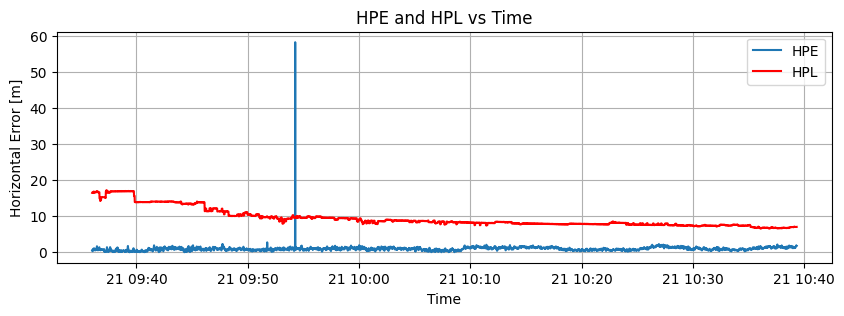

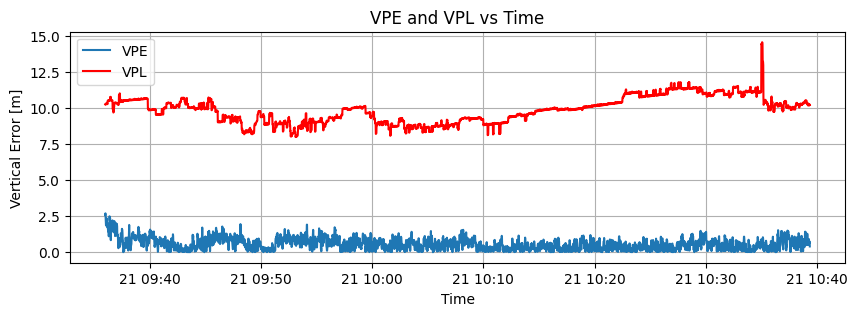

In [ ]:
# Calcular a data em timestamps
Epoch = datetime(1980 , 1 , 6)
week_start = Epoch + timedelta ( weeks = 1963)
timestamps = [ week_start + timedelta ( seconds = t ) for t in df["RX_TOM"]]

# Erro Plano Horizontal

plt.figure(figsize=(10,3))
plt.plot(timestamps, HPE, label = 'HPE')
plt.plot(timestamps, NS_HPL, color = 'r',label = 'HPL')
plt.grid()
plt.legend()
plt.ylabel("Horizontal Error [m]")
plt.xlabel("Time")
plt.title('HPE and HPL vs Time')

# Erro Plano Vertical 
VPE = [abs(x) for x in VPE] # Para poder comparar com o VPL

plt.figure(figsize=(10,3))
plt.plot(timestamps, VPE, label = 'VPE')
plt.plot(timestamps, NS_VPL, color = 'r', label = 'VPL')
plt.grid()
plt.legend()
plt.ylabel("Vertical Error [m]")
plt.xlabel("Time")
plt.title('VPE and VPL vs Time')


### Satélites Observados e Utilizados

Text(0.5, 1.0, 'Observed & Used Satelites vs Time')

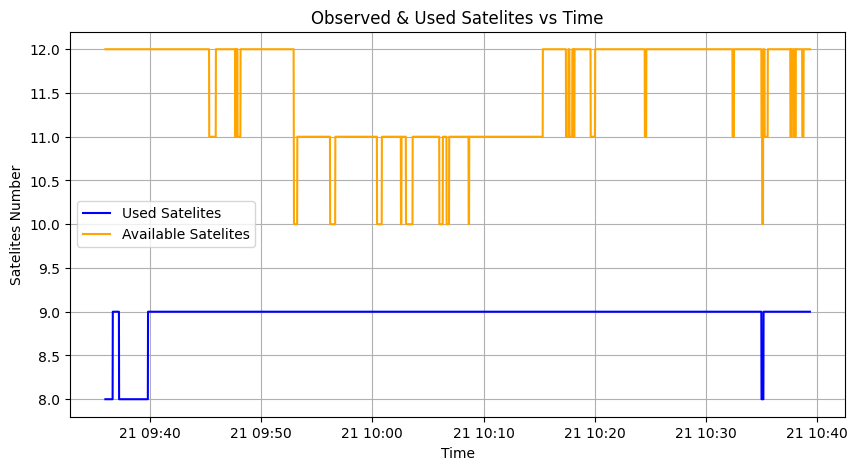

In [126]:
# Satélites Observados e Utilizados para Lock
plt.figure(figsize=(10,5))
plt.plot(timestamps, NSV_USED, color = 'b', label = 'Used Satelites')
plt.plot(timestamps, NSV_LOCK, color = 'orange', label = 'Available Satelites')
plt.grid()
plt.legend()
plt.ylabel("Satelites Number")
plt.xlabel("Time")
plt.title('Observed & Used Satelites vs Time')

## 6.
Determinar os correspondentes parâmetros de desempenho (exatidão, integridade, disponibilidade e continuidade)





## 7. 
Identificar eventuais eventos de integridade, indicando todas as suas características que considerem relevantes

## 8. 
Apresentar e comentar os resultados obtidos. 